Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

Step 2: Load Test Dataset

In [2]:
X_test = pd.read_csv("../data/processed/X_test_engineered.csv")

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

Step 3: Load Saved Models

In [2]:
import joblib

lr = joblib.load("../models/logistic_regression.pkl")

dt = joblib.load("../models/decision_tree.pkl")

rf = joblib.load("../models/random_forest_model.pkl")

Step 4: Make Predictions

In [7]:
lr_pred = lr.predict(X_test)

dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

Step 5: Create Evaluation Function

In [8]:
def evaluate(name, y_true, y_pred):
    
    accuracy = accuracy_score(y_true, y_pred)
    
    precision = precision_score(y_true, y_pred)
    
    recall = recall_score(y_true, y_pred)
    
    f1 = f1_score(y_true, y_pred)

    print(f"\n{name}")
    print("-"*40)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")

    print(classification_report(y_true, y_pred))

    return accuracy, precision, recall, f1

Step 6: Evaluate All Models

In [9]:
lr_results = evaluate(
    "Logistic Regression",
    y_test,
    lr_pred
)


Logistic Regression
----------------------------------------
Accuracy : 0.9752405455891164
Precision: 0.05623306233062331
Recall   : 0.8736842105263158
F1 Score : 0.10566518141311267

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [10]:
dt_results = evaluate(
    "Decision Tree",
    y_test,
    dt_pred
)


Decision Tree
----------------------------------------
Accuracy : 0.999048391076023
Precision: 0.7204301075268817
Recall   : 0.7052631578947368
F1 Score : 0.7127659574468085

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746



In [11]:
rf_results = evaluate(
    "Random Forest",
    y_test,
    rf_pred
)


Random Forest
----------------------------------------
Accuracy : 0.9995065731505305
Precision: 0.971830985915493
Recall   : 0.7263157894736842
F1 Score : 0.8313253012048193

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



Step 7: Confusion Matrix

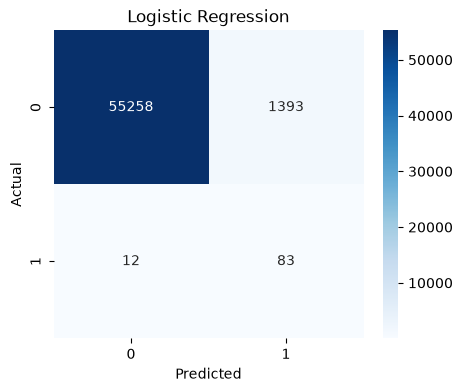

In [32]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "../figures/confusion_matrix_lr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

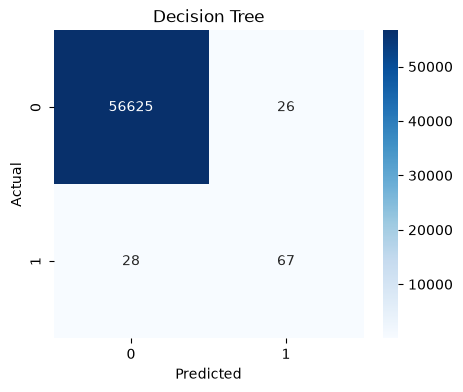

In [33]:
cm = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "../figures/confusion_matrix_dt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

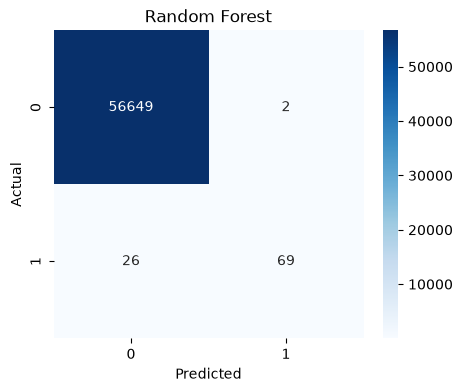

In [34]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "../figures/confusion_matrix_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 8: ROC Curve

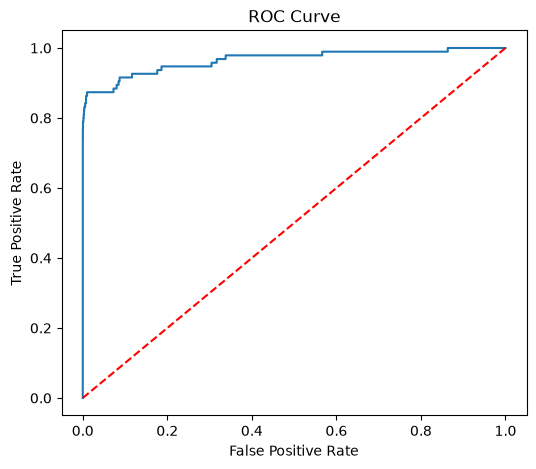

In [35]:
lr_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    lr_prob
)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.savefig(
    "../figures/roc_curve_lr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

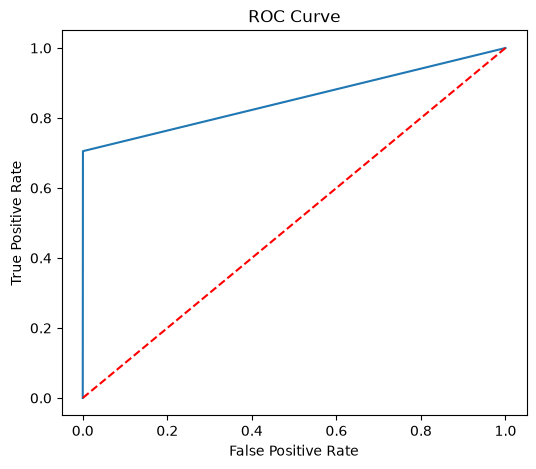

In [36]:
dt_prob = dt.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    dt_prob
)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.savefig(
    "../figures/roc_curve_dt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

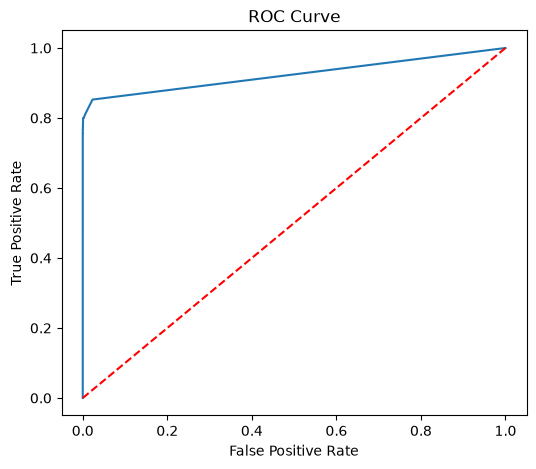

In [37]:
rf_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.savefig(
    "../figures/roc_curve_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 9: ROC-AUC Score

In [25]:
auc = roc_auc_score(
    y_test,
    lr_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9658392242808925


In [24]:
auc = roc_auc_score(
    y_test,
    dt_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8524021037395169


In [26]:
auc = roc_auc_score(
    y_test,
    rf_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9239444837225895


Step 10: Compare Models

In [27]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_results[0],
        dt_results[0],
        rf_results[0]
    ],

    "Precision":[
        lr_results[1],
        dt_results[1],
        rf_results[1]
    ],

    "Recall":[
        lr_results[2],
        dt_results[2],
        rf_results[2]
    ],

    "F1 Score":[
        lr_results[3],
        dt_results[3],
        rf_results[3]
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.975241,0.056233,0.873684,0.105665
1,Decision Tree,0.999048,0.720430,0.705263,0.712766
2,Random Forest,0.999507,0.971831,0.726316,0.831325


Step 11: Visualize Comparison

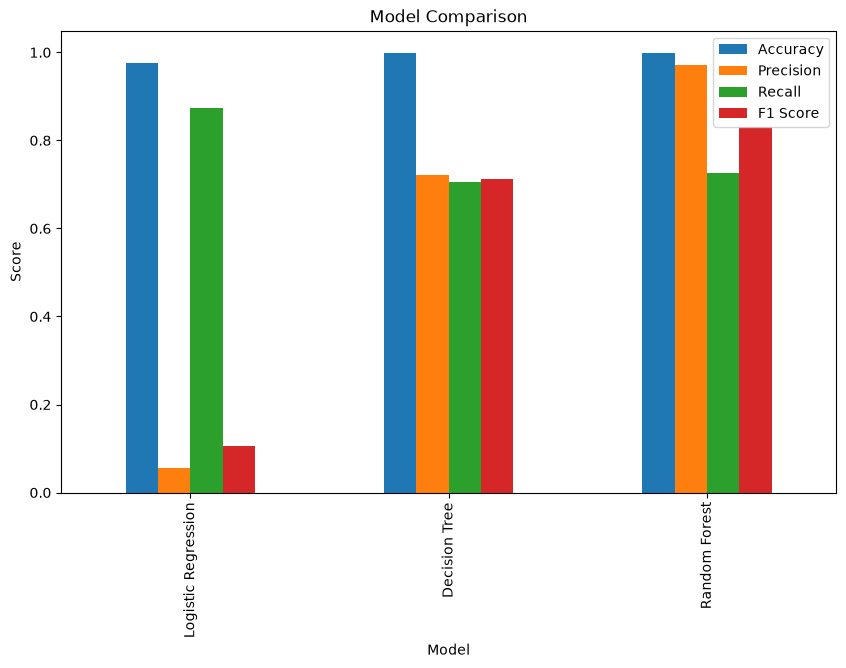

In [31]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")

plt.title("Model Comparison")

plt.savefig(
    "../figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 12: Select Best Model

In [29]:
best_model = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.999507,0.971831,0.726316,0.831325
1,Decision Tree,0.999048,0.720430,0.705263,0.712766
0,Logistic Regression,0.975241,0.056233,0.873684,0.105665


Step 13: Save Results

In [30]:
comparison.to_csv(
    "../reports/model_evaluation.csv",
    index=False
)

In [3]:
import joblib

joblib.dump(rf,"../app/model.pkl")

['../app/model.pkl']